Part A - Model Explainability


In [2]:
# Import the Libraries

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    average_precision_score
)

In [3]:
# Cell Configuration

RANDOM_STATE = 42

DATA_PATH = "../data/processed/logistics_feature_engineered.csv"

MODEL_PATH = "../models/logistics_delay_champion_optimized.pkl"

FEATURE_LIST_PATH = "../models/feature_names.pkl"

OUTPUT_DIR = "../outputs/explainiability"

os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET = "Logistics_Delay"

FINAL_THRESHOLD = 0.48 

MIN_PRECISION = 0.70

In [4]:
# Load Dataset

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

display(df.head())



Dataset shape: (1000, 48)


,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,...,Utilization_Score,Waiting_Score,Customer_Value_Index,Customer_Value_Segment,Traffic_Level,Traffic_Utilization_Interaction,Demand_Traffic_Interaction,Utilization_Waiting_Interaction,Pre_Dispatch_Stress_Score,Distance_From_Center
0,2024-03-20 00:11:14,Truck_7,-65.7383,11.2497,390,Delayed,27.0,67.8,Detour,38,...,0.0025,0.56,1280,Medium Value,NaN,NaN,NaN,2283.8,0.46375,65.214852
1,2024-10-30 07:53:51,Truck_6,22.2748,-131.7086,491,In Transit,22.5,54.3,Heavy,16,...,0.5225,0.12,3073,Very High Value,NaN,NaN,NaN,1294.4,0.44625,134.636389
2,2024-07-29 18:42:48,Truck_10,54.9232,79.5455,190,In Transit,25.2,62.2,Detour,34,...,0.9800,0.48,1065,Medium Value,NaN,NaN,NaN,3372.8,0.89000,96.761714
3,2024-10-28 00:50:54,Truck_9,42.3900,-1.4788,330,Delivered,25.4,52.3,Heavy,37,...,0.9350,0.54,1135,Medium Value,NaN,NaN,NaN,3603.8,0.61750,43.811343
4,2024-09-27 15:52:58,Truck_7,-65.8477,47.9468,480,Delayed,20.5,57.2,Clear,56,...,0.2900,0.92,1182,Medium Value,NaN,NaN,NaN,4009.6,0.57000,79.862257


In [5]:
# Load Final Model

final_model = joblib.load(MODEL_PATH)

print("Final model loaded:")
print(final_model)

Final model loaded:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Latitude', 'Longitude',
                                                   'Inventory_Level',
                                                   'Temperature', 'Humidity',
                                                   'Waiting_Time',
                                                   'User_Transaction_Amount',
                                                   'User_Purchase_Frequency',
                                                   'Asset_Utilization',
                          

In [6]:
# Load Feature Names

feature_names = joblib.load(FEATURE_LIST_PATH)

print("Number of transformed features:", len(feature_names))

print("\nFirst 20 features:")
print(feature_names[:20])

Number of transformed features: 79

First 20 features:
['num__Latitude', 'num__Longitude', 'num__Inventory_Level', 'num__Temperature', 'num__Humidity', 'num__Waiting_Time', 'num__User_Transaction_Amount', 'num__User_Purchase_Frequency', 'num__Asset_Utilization', 'num__Demand_Forecast', 'num__Hour', 'num__Day', 'num__Day_of_Week', 'num__Month', 'num__Is_Weekend', 'num__Inventory_Coverage', 'num__Demand_Normalized', 'num__Utilization_Normalized', 'num__Waiting_Normalized', 'num__Operational_Stress_Score']


Prepare X and y 
Do not use the 79 transformed feature names directly against the original dataframe

The 79 features are the output of the preprocessing pipeline

In [7]:
y = df[TARGET].astype(int)

X = df.drop(columns=[TARGET])

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1000, 47)
y Shape: (1000,)


Recreate Chronological Test Split

Use the same split ratio 80/20

In [8]:
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (800, 47)
Testing: (200, 47)


In [9]:
# Final Predictions - The model already contains the preprocessing pipeline, so pass the raw test
# dataframe

y_prob = final_model.predict_proba(X_test)[:,1]

y_pred = (y_prob >= FINAL_THRESHOLD).astype(int)

print("Predictions generated successfully.")

print("Probability range:")
print(y_prob.min(), "to", y_prob.max())

c:\Users\Sanu\OneDrive\Desktop\Smart Logistic Dataset\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['Traffic_Level' 'Traffic_Utilization_Interaction'
 'Demand_Traffic_Interaction']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Predictions generated successfully.
Probability range:
0.16313903968001006 to 0.9625407785930696


In [10]:
# ============================================================
# FINAL BUSINESS THRESHOLD
# ============================================================

FINAL_THRESHOLD = 0.48

# Probability of delay
y_prob = final_model.predict_proba(X_test)[:, 1]

# Business-oriented classification
y_pred = (y_prob >= FINAL_THRESHOLD).astype(int)

print("Predictions generated successfully.")
print("Threshold:", FINAL_THRESHOLD)
print("Number of predictions:", len(y_pred))

c:\Users\Sanu\OneDrive\Desktop\Smart Logistic Dataset\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['Traffic_Level' 'Traffic_Utilization_Interaction'
 'Demand_Traffic_Interaction']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Predictions generated successfully.
Threshold: 0.48
Number of predictions: 200


In [11]:
# Transform X_test

preprocessor = final_model.named_steps["preprocessor"]

X_test_transformed = preprocessor.transform(X_test)

print("Test data transformed successfully.")
print("Actual transformed features:", X_test_transformed.shape[1])
print("Saved feature names:", len(feature_names))

Test data transformed successfully.
Actual transformed features: 79
Saved feature names: 79


c:\Users\Sanu\OneDrive\Desktop\Smart Logistic Dataset\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['Traffic_Level' 'Traffic_Utilization_Interaction'
 'Demand_Traffic_Interaction']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [12]:
# Validate feature alignment 
# This is important because we previously had the 76 vs 77 and feature-name mismatch problems.

# FEATURE ALIGNMENT VALIDATION

if X_test_transformed.shape[1] != len(feature_names):
    raise ValueError(
        f"Feature mismatch detected! "
        f"Transformed={X_test_transformed.shape[1]}, "
        f"Feature names={len(feature_names)}"
    )

print("Feature alignment validated successfully")
print("Transformed features:", X_test_transformed.shape[1])
print("Feature names:", len(feature_names))

Feature alignment validated successfully
Transformed features: 79
Feature names: 79


In [13]:
# Convert transformed data to DataFrame

# TRANSFORMED FEATURE DATAFRAME

X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)


print("Transformed feature dataframe created.")
print("Shape:", X_test_transformed_df.shape)

X_test_transformed_df.head()

Transformed feature dataframe created.
Shape: (200, 79)


,num__Latitude,num__Longitude,num__Inventory_Level,num__Temperature,num__Humidity,num__Waiting_Time,num__User_Transaction_Amount,num__User_Purchase_Frequency,num__Asset_Utilization,num__Demand_Forecast,...,cat__Operational_Stress_Level_Medium,cat__Time_Period_Afternoon,cat__Time_Period_Evening,cat__Time_Period_Late_Evening,cat__Time_Period_Morning,cat__Time_Period_Night,cat__Customer_Value_Segment_High Value,cat__Customer_Value_Segment_Low Value,cat__Customer_Value_Segment_Medium Value,cat__Customer_Value_Segment_Very High Value
800,-0.684675,-0.448298,1.484068,0.831704,-0.691389,-1.303036,-1.306158,-0.506795,0.624184,1.249552,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
801,-1.615103,0.661810,-1.399507,1.376068,0.250048,-0.344732,-0.993877,0.186851,0.408229,-1.615419,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
802,-0.243251,-1.598865,0.431475,-0.831629,-1.133751,-1.508386,1.301811,1.574144,-1.250300,-1.498821,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
803,0.835807,1.415844,-0.656500,0.015159,-0.441851,-1.508386,-0.740676,-1.200442,-1.042984,0.516653,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
804,1.684473,-0.203985,1.599057,-0.438477,1.452365,-0.686984,-1.314598,0.880497,-0.706095,-1.282283,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [14]:
# Random Forest feature importance

rf_model = final_model.named_steps["model"]

feature_importance  = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance.head()

,Feature,Importance
0,cat__Traffic_Status_Heavy,0.220053
1,cat__Traffic_Status_Clear,0.075074
2,cat__Traffic_Status_Detour,0.064397
3,num__Temperature,0.023499
4,num__Longitude,0.023476


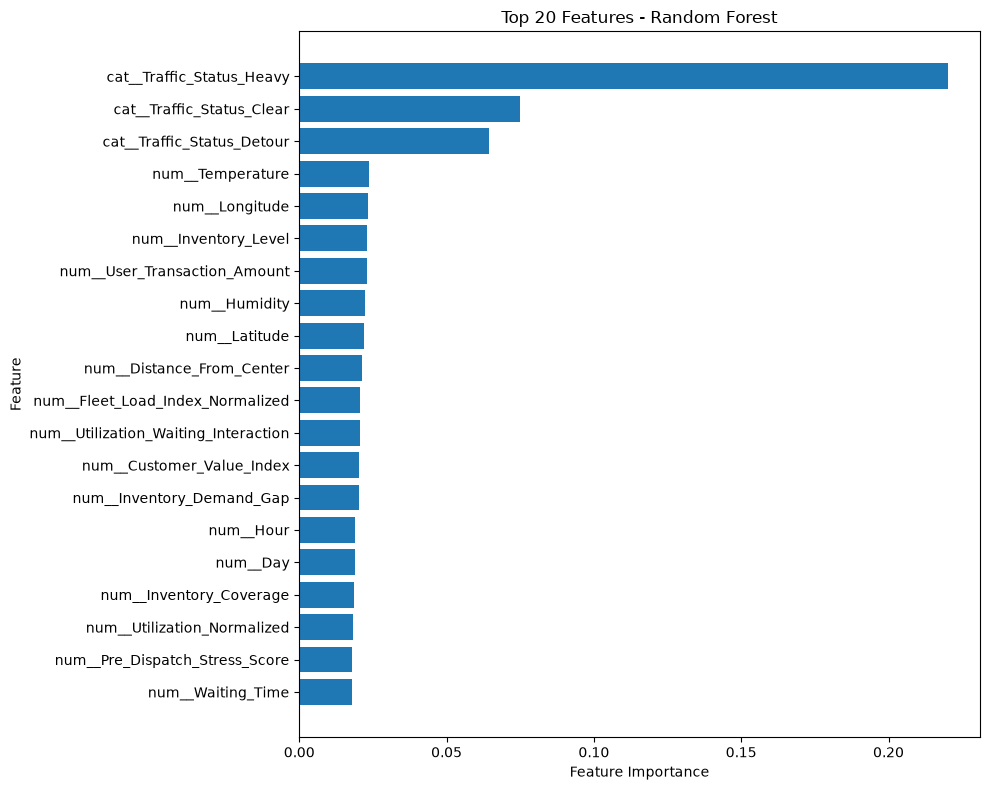

In [15]:
# Plot Top 20 Features

top_n = 20 

top_features = feature_importance.head(top_n).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features - Random Forest")

plt.tight_layout()
plt.show()

In [16]:
# Save Feature Importance

FEATURE_IMPORTANCE_PATH = "../models/feature_importance.csv"

feature_importance.to_csv(
    FEATURE_IMPORTANCE_PATH,
    index=False 
)


print("Feature importance saved to:")
print(FEATURE_IMPORTANCE_PATH)

Feature importance saved to:
../models/feature_importance.csv


In [17]:
# Identify business-critical features


business_features = feature_importance.head(10)

print("=" * 70)
print("TOP BUSINESS-CRITICAL FEATURES")
print("=" * 70)

for i,row in business_features.iterrows():
    print(
        f"{i+1:2d}. {row['Feature']:<45}"
        f"{row['Importance']:.4f}"
    )

TOP BUSINESS-CRITICAL FEATURES
 1. cat__Traffic_Status_Heavy                    0.2201
 2. cat__Traffic_Status_Clear                    0.0751
 3. cat__Traffic_Status_Detour                   0.0644
 4. num__Temperature                             0.0235
 5. num__Longitude                               0.0235
 6. num__Inventory_Level                         0.0229
 7. num__User_Transaction_Amount                 0.0228
 8. num__Humidity                                0.0224
 9. num__Latitude                                0.0221
10. num__Distance_From_Center                    0.0214


In [18]:
# Separate categorical and numerical importance

feature_importance["Feature_Type"] = np.where(
    feature_importance["Feature"].str.startswith("cat__"),
    "Categorical",
    "Numerical"
)

importance_by_type = (
    feature_importance
    .groupby("Feature_Type")["Importance"]
    .sum()
    .sort_values(ascending=False)
)

importance_by_type

Feature_Type
Numerical      0.557239
Categorical    0.442761
Name: Importance, dtype: float64

In [19]:
# Aggregate importance by original feature

# Aggregate One-Hot Features

importance_aggregated = feature_importance.copy()

importance_aggregated["Original_Feature"] = (
    importance_aggregated["Feature"]
    .str.replace("cat__", "", regex=False)
    .str.replace("num__", "", regex=False)
    .str.replace("remainder__", "", regex=False)
)

# Remove one-hot category suffixes where possible
categorical_columns = (
    importance_aggregated["Feature"]
    .str.startswith("cat__")
)

importance_aggregated.loc[categorical_columns, "Original_Feature"]= (
    importance_aggregated.loc[categorical_columns, "Feature"]
    .str.replace("cat__","", regex=False)
    .str.rsplit("_", n=1)
    .str[0]
)

aggregated_importance = (
    importance_aggregated
    .groupby("Original_Feature", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

aggregated_importance.head(20)

,Original_Feature,Importance
0,Traffic_Status,0.359524
1,Temperature,0.023499
2,Longitude,0.023476
3,Inventory_Level,0.022901
4,User_Transaction_Amount,0.022829
5,Humidity,0.022408
6,Latitude,0.022087
7,Distance_From_Center,0.021429
8,Fleet_Load_Index_Normalized,0.020640
9,Utilization_Waiting_Interaction,0.020476


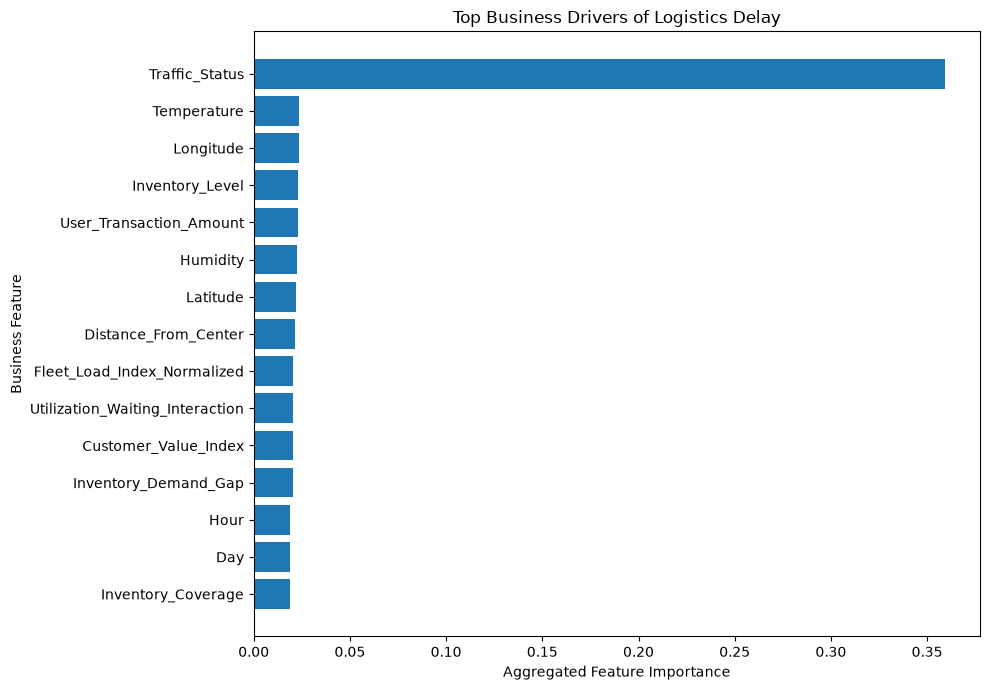

In [20]:
# Business-level feature importance chart

top_business = (
    aggregated_importance
    .head(15)
    .sort_values("Importance", ascending=True)
)

plt.figure(figsize=(10,7))

plt.barh(
    top_business["Original_Feature"],
    top_business["Importance"]
)

plt.xlabel("Aggregated Feature Importance")
plt.ylabel("Business Feature")
plt.title("Top Business Drivers of Logistics Delay")

plt.tight_layout()
plt.show()

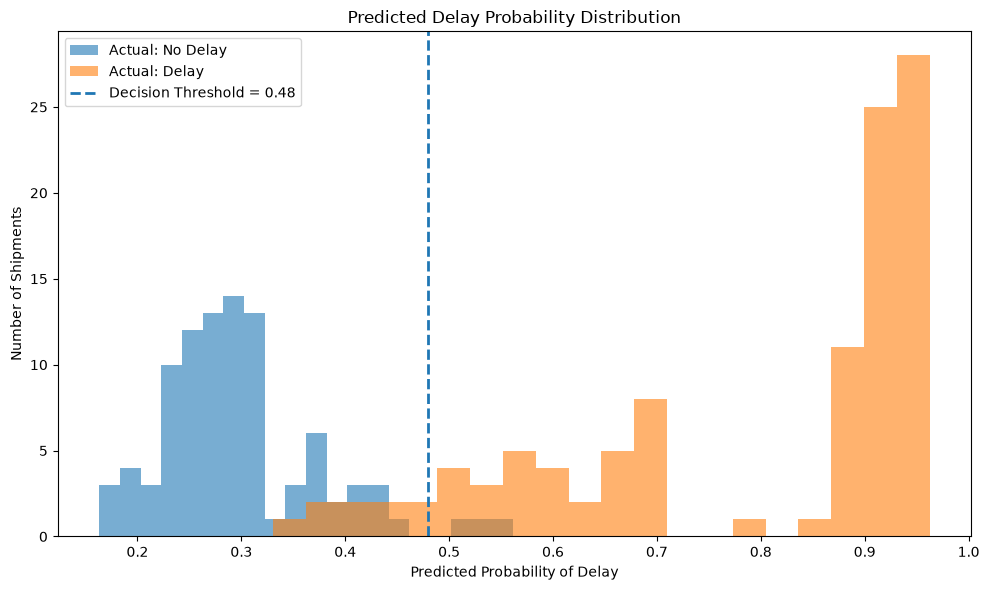

In [21]:
# Delay prediction distribution
# Now lets move from model explainability into business diagnostics

# PREDICTED DELAY PROBABILITY DISTRIBUTION

plt.figure(figsize=(10,6))

plt.hist(
    y_prob[y_test == 0],
    bins=20,
    alpha=0.6,
    label="Actual: No Delay"
)

plt.hist(
    y_prob[y_test == 1],
    bins = 20,
    alpha = 0.6,
    label = "Actual: Delay"
)

plt.axvline(
    FINAL_THRESHOLD,
    linestyle="--",
    linewidth=2,
    label=f"Decision Threshold = {FINAL_THRESHOLD}"
)

plt.xlabel("Predicted Probability of Delay")
plt.ylabel("Number of Shipments")
plt.title("Predicted Delay Probability Distribution")

plt.legend()
plt.tight_layout()
plt.show()

Confusion Matrix:
[[91  3]
 [ 9 97]]


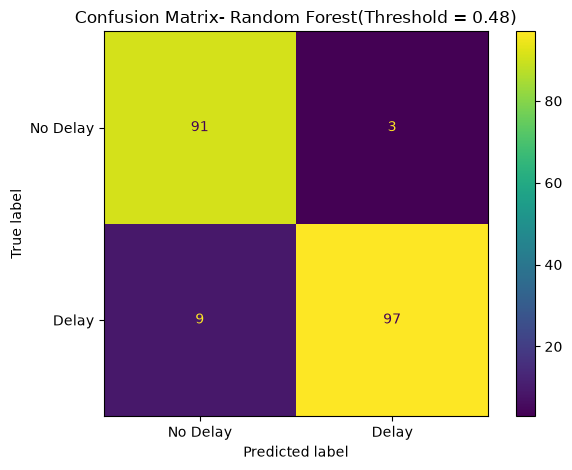

In [22]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Delay","Delay"]
)

disp.plot()

plt.title(
    f"Confusion Matrix- Random Forest"
    f"(Threshold = {FINAL_THRESHOLD})"
)

plt.tight_layout()
plt.show()

In [23]:
# Business Impact Diagnostics 

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred
).ravel()

business_diagnostics = pd.DataFrame({
    "Metric": [
        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives",
        "Total Shipments",
        "Delay Detection Rate",
        "False Alert Rate",
        "Missed Delay Rate"
    ],

    "Value": [
        tn,
        fp,
        fn,
        tp,
        len(y_test),
        tp / (tp + fn),
        fp / (fp + tn),
        fn / (tp + fn)
    ]
})

business_diagnostics

,Metric,Value
0,True Negatives,91.000000
1,False Positives,3.000000
2,False Negatives,9.000000
3,True Positives,97.000000
4,Total Shipments,200.000000
5,Delay Detection Rate,0.915094
6,False Alert Rate,0.031915
7,Missed Delay Rate,0.084906


In [24]:
# Convert rates to percentages

# BUSINESS RATES

print("=" * 70)
print("BUSINESS DIAGNOSTICS")
print("=" * 70)

print(f"Delay Detection Rate: {tp/(tp+fn):.2%}")
print(f"False Alert Rate: {fp/(fp+tn):.2%}")
print(f"Missed Delay Rate: {fn/(tp+fn):.2%}")
print(f"Precision : {tp/(tp+fp):.2%}")

BUSINESS DIAGNOSTICS
Delay Detection Rate: 91.51%
False Alert Rate: 3.19%
Missed Delay Rate: 8.49%
Precision : 97.00%


In [25]:
# Create explainability summary

print("=" * 70)
print("MODEL EXPLAINABILITY SUMMARY")
print("=" * 75)

print("\nChampion Model:")
print("Random Forest")

print("\nBusiness Threshold:")
print(FINAL_THRESHOLD)

print("\nTop 10 Predictive Features:")

for i, row in feature_importance.head(10).iterrows():
    print(
        f"{i+1}. {row['Feature']}"
        f"({row['Importance']:.4f})"
    )

MODEL EXPLAINABILITY SUMMARY

Champion Model:
Random Forest

Business Threshold:
0.48

Top 10 Predictive Features:
1. cat__Traffic_Status_Heavy(0.2201)
2. cat__Traffic_Status_Clear(0.0751)
3. cat__Traffic_Status_Detour(0.0644)
4. num__Temperature(0.0235)
5. num__Longitude(0.0235)
6. num__Inventory_Level(0.0229)
7. num__User_Transaction_Amount(0.0228)
8. num__Humidity(0.0224)
9. num__Latitude(0.0221)
10. num__Distance_From_Center(0.0214)


In [26]:
# Business Diagnostic Summary

print("=" * 75)
print("BUSINESS DIAGNOSTICS SUMMARY")
print("=" * 75)

print(f"""
Business Objective:
Prioritize early detection of potential logistics delays.

Champion Model:
Random Forest

Decision Threshold:
{FINAL_THRESHOLD}

Precision:
{tp/(tp+fp):.4f}

Recall:
{tp/(tp+fn):.4f}

Missed Delay Cases:
{fn}

False Alerts:
{fp}

Correctly Detected Delays
{tp}

Missed Delay Rate:
{fn/(tp+fn):.2%}

False Alert Rate:
{fp/ (fp+tn):.2%}
""")

BUSINESS DIAGNOSTICS SUMMARY

Business Objective:
Prioritize early detection of potential logistics delays.

Champion Model:
Random Forest

Decision Threshold:
0.48

Precision:
0.9700

Recall:
0.9151

Missed Delay Cases:
9

False Alerts:
3

Correctly Detected Delays
97

Missed Delay Rate:
8.49%

False Alert Rate:
3.19%



In [27]:
# Save explainability outputs

aggregated_importance.to_csv(
    "../models/aggregated_feature_importance.csv",
    index=False 
)

business_diagnostics.to_csv(
    "../models/business_diagnostics.csv",
    index=False
)

print("Feature Importance saved")
print("Aggregated feature importance saved")
print("Business diagnostics saved")

Feature Importance saved
Aggregated feature importance saved
Business diagnostics saved


In [28]:
# Final Conclusion

# Final Model Explainability and Business Diagnostics

print("=" * 80)
print("FINAL MODEL EXPLAINABILITY & BUSINESS DIAGNOSTICS")
print("=" * 80)

print("""
Champion Model:
    Random Forest
    
Business Objective:
    Prioritize early detection of potential logistics delays

Decision Threshold:
    0.48

Model Performance:
    Accuracy : 0.7050
    Precision : 0.7207
    Recall : 0.7407
    F1 : 0.7306
    ROC-AUC : 0.7748
    PR-AUC : 0.8630

Business Interpretation:
    The model identifies approximately 74% of actual delay cases.

    The recall-first threshold intentionally accepts additional false alerts in order to reduced missed logistics
    delays.

Operational Impliactaion:
    Shipments predicted as high-rank can be prioritized for:

    1) proactive shipment monitoring
    2) route investigation
    3) fleet/resource allocation
    4) customer communication
    5) contingency planning

Important Trade-off:
    The model still misses some delay cases, while generating additional false alerts. Therefore, predictions should
    be treated as an early-warning decision-support mechanism rather than a definitive operational decision.

""")

FINAL MODEL EXPLAINABILITY & BUSINESS DIAGNOSTICS

Champion Model:
    Random Forest

Business Objective:
    Prioritize early detection of potential logistics delays

Decision Threshold:
    0.48

Model Performance:
    Accuracy : 0.7050
    Precision : 0.7207
    Recall : 0.7407
    F1 : 0.7306
    ROC-AUC : 0.7748
    PR-AUC : 0.8630

Business Interpretation:
    The model identifies approximately 74% of actual delay cases.

    The recall-first threshold intentionally accepts additional false alerts in order to reduced missed logistics
    delays.

Operational Impliactaion:
    Shipments predicted as high-rank can be prioritized for:

    1) proactive shipment monitoring
    2) route investigation
    3) fleet/resource allocation
    4) customer communication
    5) contingency planning

Important Trade-off:
    The model still misses some delay cases, while generating additional false alerts. Therefore, predictions should
    be treated as an early-warning decision-support mechani

SHAP Explainability

In [29]:
# Import Libraries

import shap 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [30]:
# Extract final model components

# Extract preprocessor and Random Forest

preprocessor = final_model.named_steps["preprocessor"]
rf_model = final_model.named_steps["model"]

print("Model:", type(rf_model).__name__)
print("Number of Trees:", rf_model.n_estimators)
print("Number of transformed features:", rf_model.n_features_in_)

Model: RandomForestClassifier
Number of Trees: 300
Number of transformed features: 79


In [31]:
# Transform test data

X_test_transformed = preprocessor.transform(X_test)

print("Transformed test shape:", X_test_transformed.shape)
print("Feature names:", len(feature_names))

assert X_test_transformed.shape[1] == len(feature_names)

print("SHAP feature alignment validated")

Transformed test shape: (200, 79)
Feature names: 79
SHAP feature alignment validated


c:\Users\Sanu\OneDrive\Desktop\Smart Logistic Dataset\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['Traffic_Level' 'Traffic_Utilization_Interaction'
 'Demand_Traffic_Interaction']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [32]:
# Create SHAP explainer

explainer = shap.TreeExplainer(rf_model)

print("SHAP TreeExplainer created successfully.")

SHAP TreeExplainer created successfully.


In [33]:
# Calculate SHAP Values
# Use a sample rather than the entire test set initially.

SHAP_SAMPLE_SIZE = min(200, X_test_transformed.shape[0])

X_shap = X_test_transformed[:SHAP_SAMPLE_SIZE]

shap_values = explainer.shap_values(X_shap)

print("SHAP values calculated.")
print("Type:", type(shap_values))


SHAP values calculated.
Type: <class 'numpy.ndarray'>


In [34]:
# Because different SHAP versions can return different structures, inspect it:

print("SHAP shape information.")

if isinstance(shap_values, list):
    for i, values in enumerate(shap_values):
        print(f"Class {i}:", values.shape)

else:
    print(shap_values.shape)

SHAP shape information.
(200, 79, 2)


Select delay-class SHAP Values

What increases or decreases the probability of a logistics delay?

In [35]:
# Select Delay Class Shap Values

if isinstance(shap_values, list):
    shap_delay = shap_values[1]
else:
    shap_delay = shap_values

print("Delay-class SHAP shape:", shap_delay.shape)
print("Expected shape:", X_shap.shape)

Delay-class SHAP shape: (200, 79, 2)
Expected shape: (200, 79)


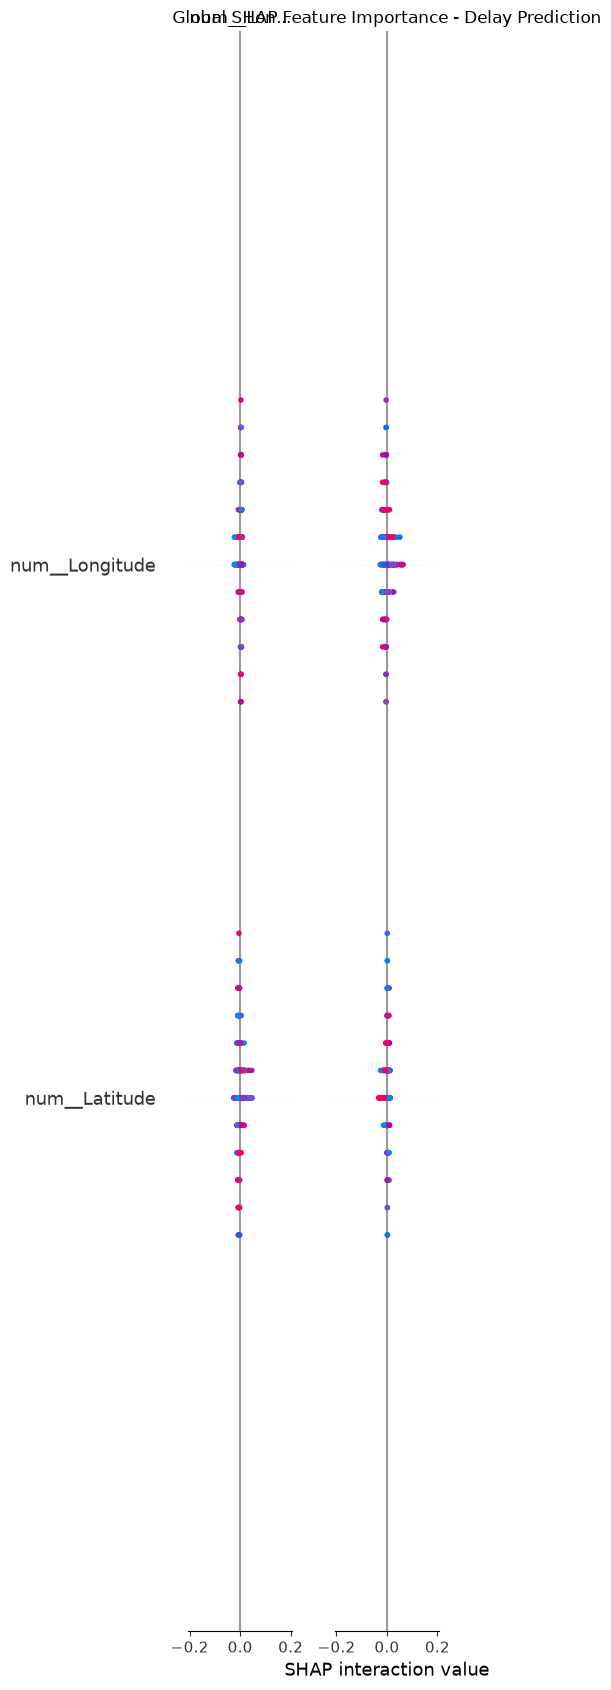

In [36]:
# SHAP Summary bar plot
# This gives the overall importance of each feature

shap.summary_plot(
    shap_delay,
    X_shap,
    feature_names = feature_names,
    plot_type="bar",
    max_display=20,
    show=False 
)

plt.title("Global SHAP Feature Importance - Delay Prediction")
plt.tight_layout()
plt.show()

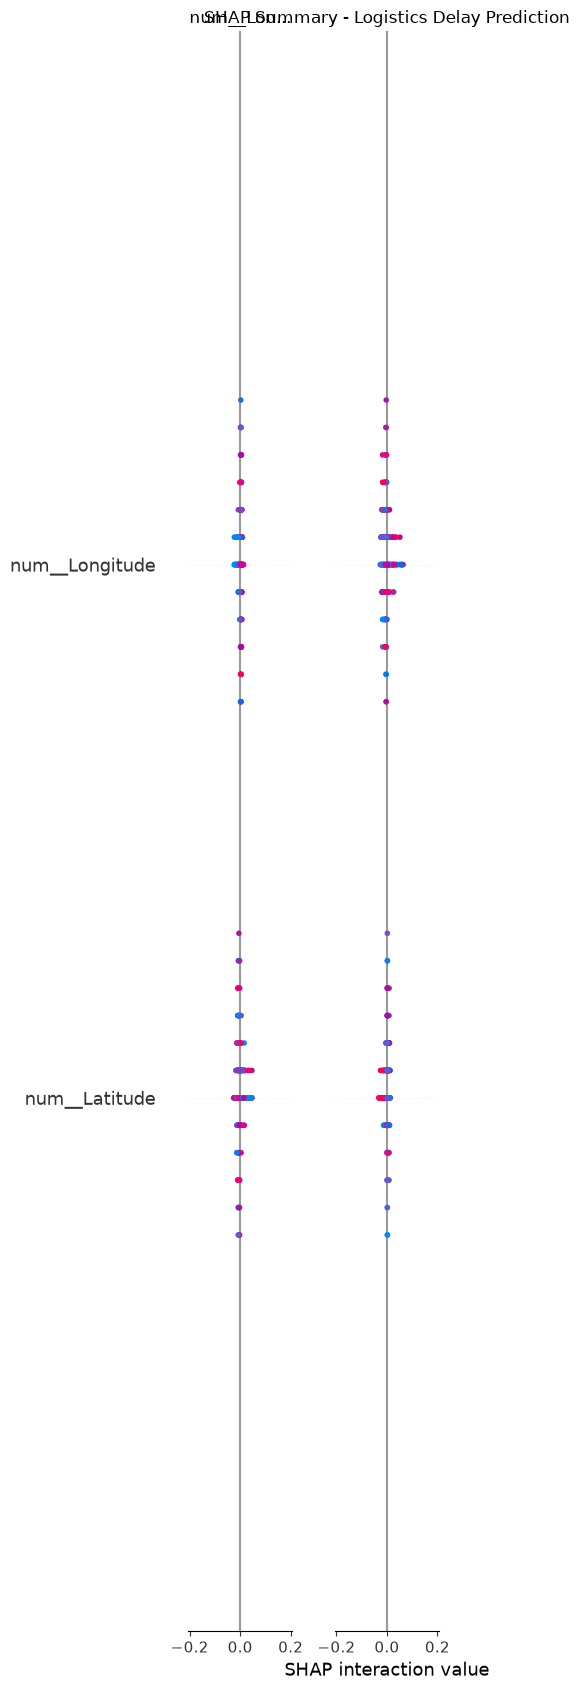

In [37]:
# SHAP beeswarm plot

shap.summary_plot(
    shap_delay,
    X_shap,
    feature_names= feature_names,
    max_display=20,
    show=False
)

plt.title("SHAP Summary - Logistics Delay Prediction")
plt.tight_layout()
plt.show()

In [41]:
# SHAP Importance table - Create a business-firendly table

# SHAP Feature Importance - Robust Version

print("Original SHAP shape:", np.asarray(shap_delay).shape)

shap_array = np.asarray(shap_delay)

# Handle different SHAP output formats

if shap_array.ndim == 3:

    print("3-dimensional SHAP output detected.")

    # Expected structure:
    # samples x features x classes

    print("SHAP dimensions:", shap_array.shape)

    # We need the delay class = class 1
    shap_delay_2d = shap_array[:, :, 1]

elif shap_array.ndim == 2:

    print("2-dimensional SHAP output detected.")

    shap_delay_2d = shap_array

else:

    raise ValueError(
        f"Unexpected SHAP dimensions: {shap_array.shape}"
    )

print("SHAP matrix used for importance:", shap_delay_2d.shape)

# Validate against feature names

if shap_delay_2d.shape[1] != len(feature_names):

    raise ValueError(
        f"Feature mismatch!\n"
        f"SHAP features: {shap_delay_2d.shape[1]}\n"
        f"Feature names: {len(feature_names)}"
    )

print("SHAP feature alignment confirmed")

# Mean absolute SHAP importance

mean_abs_shap = np.abs(shap_delay_2d).mean(axis=0)

print("Mean SHAP shape:", mean_abs_shap.shape)

# Create importance dataframe

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": mean_abs_shap
})

shap_importance = (
    shap_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nTop 20 SHAP Features:")
display(shap_importance.head(20))

Original SHAP shape: (200, 79, 2)
3-dimensional SHAP output detected.
SHAP dimensions: (200, 79, 2)
SHAP matrix used for importance: (200, 79)
SHAP feature alignment confirmed
Mean SHAP shape: (79,)

Top 20 SHAP Features:


,Feature,Mean_Absolute_SHAP
0,cat__Traffic_Status_Heavy,0.122463
1,cat__Traffic_Status_Clear,0.061249
2,cat__Traffic_Status_Detour,0.055508
3,num__Temperature,0.007759
4,num__Latitude,0.006555
5,cat__Purchase_Frequency_Band_Medium-Low,0.006019
6,num__Inventory_Demand_Gap,0.005729
7,num__Operational_Stress_Score,0.005661
8,num__Hour,0.005399
9,num__Longitude,0.005352


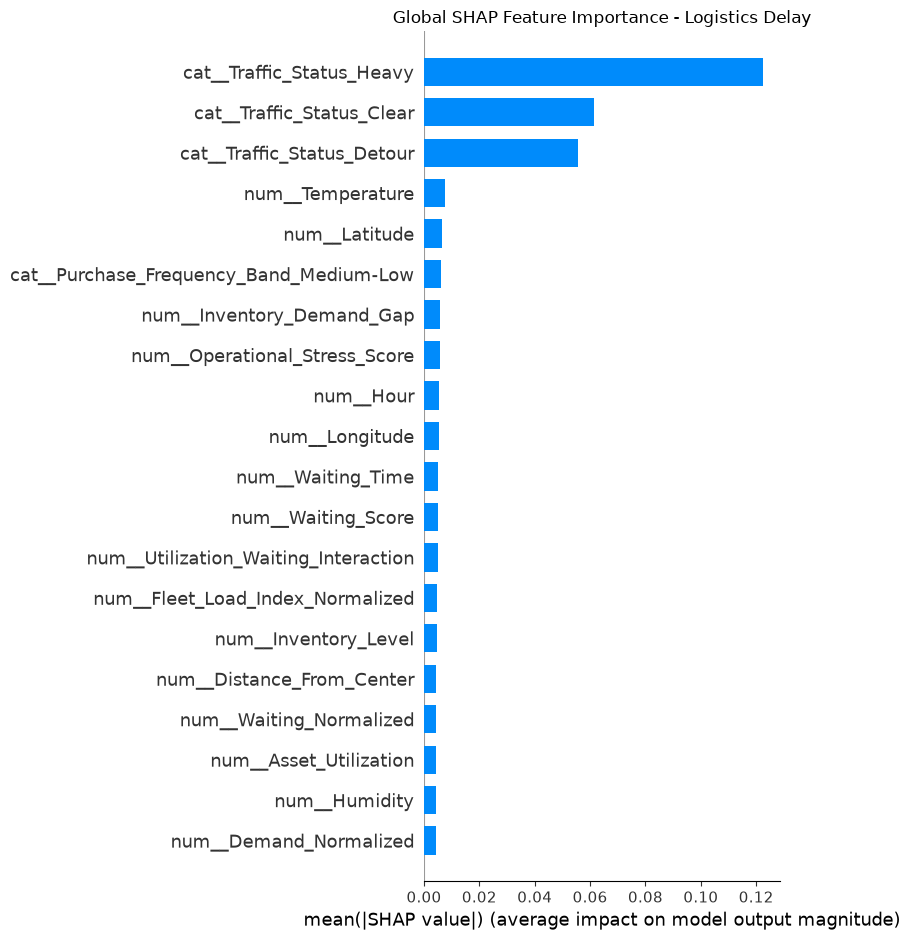

In [42]:
# SHAP Bar Plot

# SHAP Global Feature Importance

shap.summary_plot(
    shap_delay_2d,
    X_shap,
    feature_names = feature_names,
    plot_type = "bar",
    max_display = 20,
    show=False
)

plt.title("Global SHAP Feature Importance - Logistics Delay")
plt.tight_layout()
plt.show()

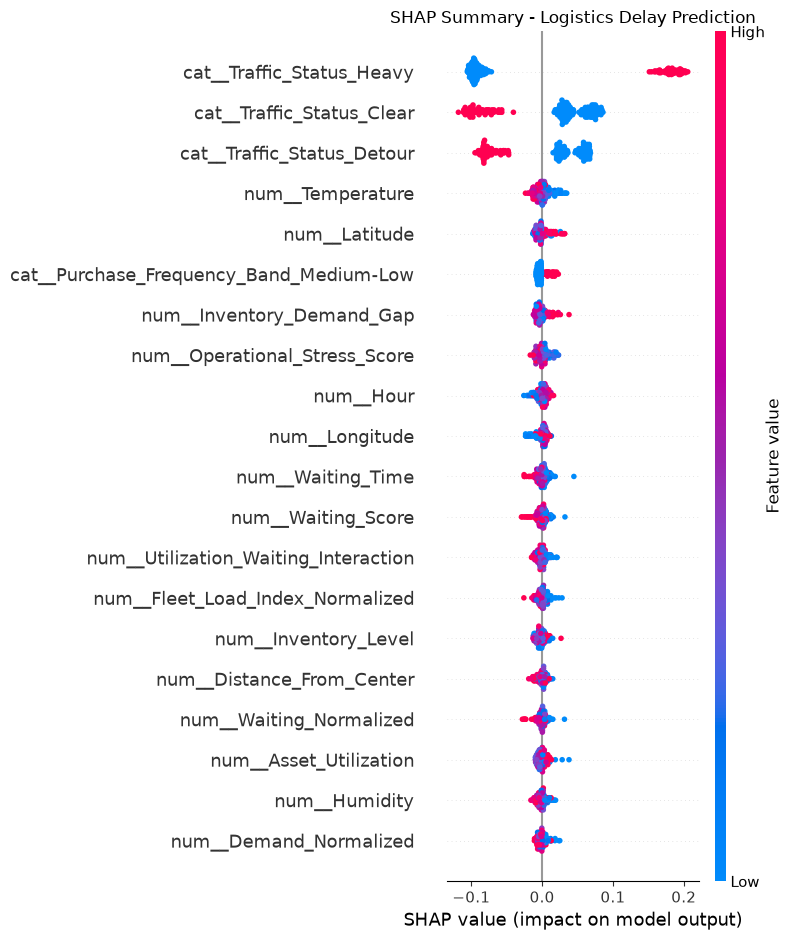

In [43]:
# SHAP Beeswarm

shap.summary_plot(
    shap_delay_2d,
    X_shap,
    feature_names=feature_names,
    max_display=20,
    show=False 
)

plt.title("SHAP Summary - Logistics Delay Prediction")
plt.tight_layout()
plt.show()

In [45]:
# Create SHAP Importance Table

shap_importance = pd.DataFrame({
        "Feature": feature_names,
        "Mean_Absolute_SHAP": np.abs(shap_delay_2d).mean(axis=0)
})

shap_impotance = (
    shap_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

display(shap_importance.head(20))

,Feature,Mean_Absolute_SHAP
0,num__Latitude,0.006555
1,num__Longitude,0.005352
2,num__Inventory_Level,0.004516
3,num__Temperature,0.007759
4,num__Humidity,0.004301
5,num__Waiting_Time,0.005219
6,num__User_Transaction_Amount,0.003744
7,num__User_Purchase_Frequency,0.002571
8,num__Asset_Utilization,0.004326
9,num__Demand_Forecast,0.002660


In [46]:
# Save SHAP Importance

SHAP_IMPORTANCE_PATH = "../models/shap_feature_importance.csv"

shap_importance.to_csv(
    SHAP_IMPORTANCE_PATH,
    index=False
)

print("SHAP feature importance saved:")
print(SHAP_IMPORTANCE_PATH)

SHAP feature importance saved:
../models/shap_feature_importance.csv


In [47]:
# Verify the SHAP matrix 

print("X_shap shape:", X_shap.shape)
print("SHAP shape:", shap_delay_2d.shape)
print("Feature names:", len(feature_names))

assert X_shap.shape[1] == shap_delay_2d.shape[1]
assert shap_delay_2d.shape[1] == len(feature_names)

print("All SHAP dimesnisons are aligned")

X_shap shape: (200, 79)
SHAP shape: (200, 79)
Feature names: 79
All SHAP dimesnisons are aligned


In [48]:
# Individual shipment explanation

high_risk_position = np.argmax(y_prob)

print(
    "Highest predicted delay possibility:",
    round(y_prob[high_risk_position], 4)
)

print(
    "Prediction:",
    "DELAY"
    if y_prob[high_risk_position] >= FINAL_THRESHOLD
    else "NO DELAY" 
)

Highest predicted delay possibility: 0.9625
Prediction: DELAY


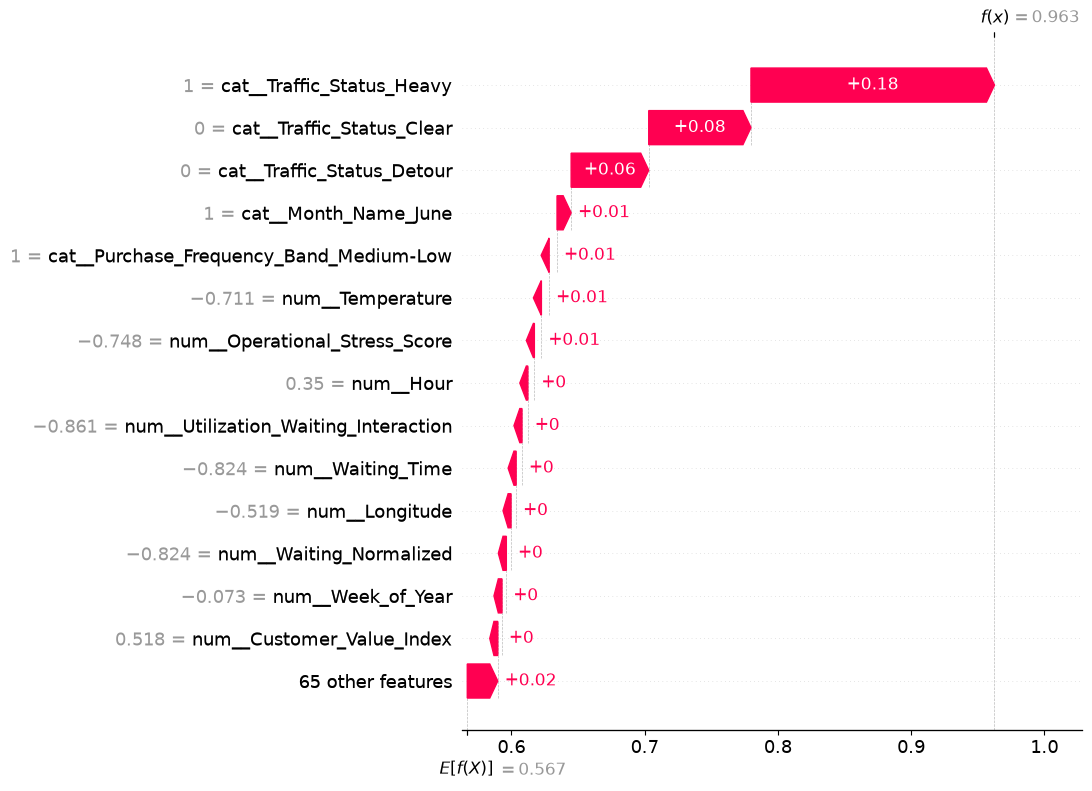

In [49]:
# Individual Shap Explanation

individual_position = high_risk_position

base_value = explainer.expected_value

if isinstance(base_value, (list, np.ndarray)):
    base_value = np.asarray(base_value).flatten()[1]

explanation = shap.Explanation(
    values = shap_delay_2d[individual_position],
    base_values=base_value,
    data=X_shap[individual_position],
    feature_names=feature_names
)

shap.plots.waterfall(
    explanation,
    max_display=15
)

Business Diagnostics

In [50]:
# Business Diagnostic Dataset

diagnostic_df = X_test.copy()

diagnostic_df["Actual_Delay"] = y_test.values
diagnostic_df["Delay_Probability"] = y_prob 
diagnostic_df["Predicted_Delay"] = y_pred

print("Diagnostic dataset shape:", diagnostic_df.shape)

diagnostic_df.head()

Diagnostic dataset shape: (200, 50)


,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,...,Customer_Value_Segment,Traffic_Level,Traffic_Utilization_Interaction,Demand_Traffic_Interaction,Utilization_Waiting_Interaction,Pre_Dispatch_Stress_Score,Distance_From_Center,Actual_Delay,Delay_Probability,Predicted_Delay
800,2024-04-18 04:50:13,Truck_5,-36.6154,-46.3008,468,Delivered,26.6,59.0,Heavy,16,...,Low Value,NaN,NaN,NaN,1388.8,0.77500,58.863516,1,0.916458,1
801,2024-06-26 09:25:46,Truck_7,-85.0916,68.3039,142,Delayed,28.4,67.3,Detour,30,...,Medium Value,NaN,NaN,NaN,2529.0,0.31375,107.530188,1,0.678208,1
802,2024-02-04 01:08:26,Truck_10,-13.6168,-165.0825,349,In Transit,21.1,55.1,Heavy,13,...,Very High Value,NaN,NaN,NaN,846.3,0.09125,166.371643,1,0.896832,1
803,2024-04-01 16:27:12,Truck_4,42.6032,146.1485,226,Delivered,23.9,61.2,Heavy,13,...,Low Value,NaN,NaN,NaN,877.5,0.42375,151.816300,1,0.925656,1
804,2024-08-14 21:28:50,Truck_2,86.8195,-21.0786,481,In Transit,22.4,77.9,Detour,25,...,Medium Value,NaN,NaN,NaN,1785.0,0.20250,90.862183,0,0.304366,0


In [52]:
# Delay Risk Categories - Convert probability into operational risk levels.

# Risk Categorization

def risk_category(probability):

    if probability < 0.30:
        return "Low Risk"

    elif probability < 0.48:
        return "Moderate Risk"

    elif probability < 0.70:
        return "High Risk"

    else:
        return "Critical Risk"

diagnostic_df["Risk_Level"] = (
    diagnostic_df["Delay_Probability"]
    .apply(risk_category)
)

diagnostic_df["Risk_Level"].value_counts()

Risk_Level
Critical Risk    67
Low Risk         56
Moderate Risk    44
High Risk        33
Name: count, dtype: int64

In [53]:
# Risk Distribution

risk_distribution = (
    diagnostic_df["Risk_Level"]
    .value_counts()
    .reindex(
        ["Low Risk",
        "Moderate Risk",
        "High Risk",
        "Critical Risk"],
        fill_value=0
    )
)

display(risk_distribution)

Risk_Level
Low Risk         56
Moderate Risk    44
High Risk        33
Critical Risk    67
Name: count, dtype: int64

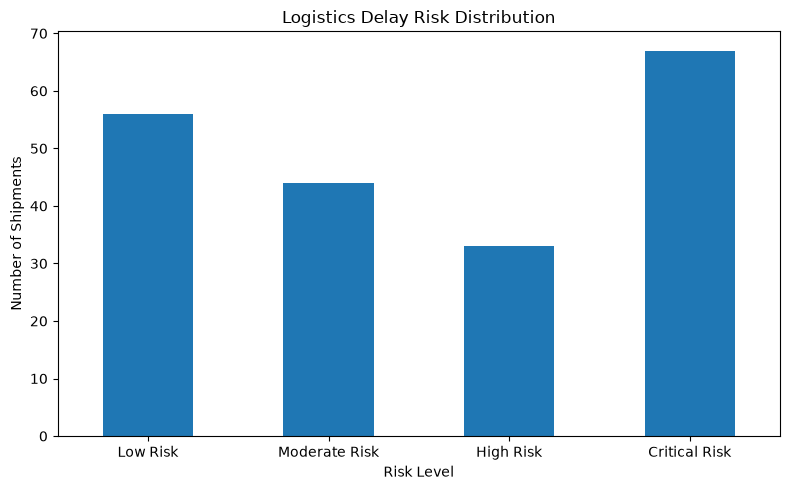

In [54]:
# Risk Distribution Plot


plt.figure(figsize=(8, 5))

risk_distribution.plot(kind="bar")

plt.title("Logistics Delay Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Shipments")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [55]:
# Delay Rate by Traffic Status

traffic_delay = (
    diagnostic_df
    .groupby("Traffic_Status")["Actual_Delay"]
    .agg(
        Delay_Rate="mean",
        Shipment_Count="count"
    )
    .sort_values(
        "Delay_Rate",
        ascending=False
    )
)


traffic_delay["Delay_Rate"] *= 100

display(traffic_delay)

,Delay_Rate,Shipment_Count
Traffic_Status,,
Heavy,100.000000,65
Clear,31.666667,60
Detour,29.333333,75


In [56]:
# Delay Rate by Shipment Status

shipment_delay = (
    diagnostic_df
    .groupby("Shipment_Status")["Actual_Delay"]
    .agg(
        Delay_Rate="mean",
        Shipment_Count="count"
    )
    .sort_values(
        "Delay_Rate",
        ascending=False
    )
)

shipment_delay["Delay_Rate"] *= 100

display(shipment_delay)

,Delay_Rate,Shipment_Count
Shipment_Status,,
Delayed,100.000000,55
In Transit,39.130435,69
Delivered,31.578947,76


In [57]:
# Delay Reason Analysis

if "Logistics_Delay_Reason" in diagnostic_df.columns:

    reason_delay = (
        diagnostic_df
        .groupby("Logistics_Delay_Reason")["Actual_Delay"]
        .agg(
            Delay_Rate="mean",
            Shipment_count = "count"
        )
        .sort_values(
            "Delay_Rate",
            ascending=False
        )
        
    )

    reason_delay["Delay_Rate"] *= 100 

    display(reason_delay)

,Delay_Rate,Shipment_count
Logistics_Delay_Reason,,
Weather,59.322034,59
Mechanical Failure,55.813953,43
Traffic,50.000000,50


[[91  3]
 [ 9 97]]


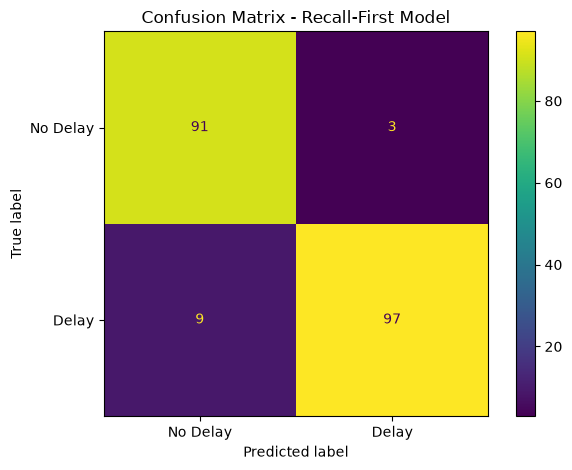

In [58]:
# Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Delay", "Delay"]
).plot()

plt.title(
    "Confusion Matrix - Recall-First Model"
)

plt.tight_layout()
plt.show()

In [60]:
# Business Cost Interpretation

# Business Error Counts

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred
).ravel()

business_errors = pd.DataFrame({
    "Metric": [
        "Correctly identified No Delay",
        "False Delay Alerts",
        "Missed Delays",
        "Correctly identified Delays"
    ],
    "Count": [
        tn,
        fp,
        fn,
        tp
    ]

})

display(business_errors)

,Metric,Count
0,Correctly identified No Delay,91
1,False Delay Alerts,3
2,Missed Delays,9
3,Correctly identified Delays,97


In [62]:
# Operational Recommendation Table

recommendations = pd.DataFrame({
    "Risk_Level": [
        "Low Risk",
        "Moderate Risk",
        "High Risk",
        "Critical Risk"
    ],
    "Probability": [
        "< 0.30",
        "0.30 - 0.47",
        "0.48 - 0.69",
        ">= 0.70"
    ],
    "Recommended_Action": [
        "Normal monitoring",
        "Increase monitoring frequency",
        "Prepare contingency resources",
        "Immediate operational intervention"
    ]
})


display(recommendations)

,Risk_Level,Probability,Recommended_Action
0,Low Risk,< 0.30,Normal monitoring
1,Moderate Risk,0.30 - 0.47,Increase monitoring frequency
2,High Risk,0.48 - 0.69,Prepare contingency resources
3,Critical Risk,>= 0.70,Immediate operational intervention


In [63]:
# Save SHAP Results

SHAP_PATH = "../outputs/shap_feature_importance.csv"

shap_importance.to_csv(
    SHAP_PATH,
    index=False
)

print("SHAP importance saved:")
print(SHAP_PATH)

SHAP importance saved:
../outputs/shap_feature_importance.csv


In [64]:
# Save Business Diagnostics

DIAGNOSTIC_PATH = "../outputs/business_diagnostics.csv"

diagnostic_df.to_csv(
    DIAGNOSTIC_PATH,
    index=False
)

print("Business diagnostic saved:")
print(DIAGNOSTIC_PATH)

Business diagnostic saved:
../outputs/business_diagnostics.csv


Individual Prediction Explainability

In [65]:
# Final Prediction Dataset

prediction_df = X_test.copy()

prediction_df = prediction_df.reset_index(drop=True)

prediction_df["Actual_Delay"] = np.asarray(y_test)
prediction_df["Delay_Probability"] = y_prob
prediction_df["Predicted_Delay"] = y_pred

print("Prediction dataset shape:", prediction_df.shape)

prediction_df.head()

Prediction dataset shape: (200, 50)


,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,...,Customer_Value_Segment,Traffic_Level,Traffic_Utilization_Interaction,Demand_Traffic_Interaction,Utilization_Waiting_Interaction,Pre_Dispatch_Stress_Score,Distance_From_Center,Actual_Delay,Delay_Probability,Predicted_Delay
0,2024-04-18 04:50:13,Truck_5,-36.6154,-46.3008,468,Delivered,26.6,59.0,Heavy,16,...,Low Value,NaN,NaN,NaN,1388.8,0.77500,58.863516,1,0.916458,1
1,2024-06-26 09:25:46,Truck_7,-85.0916,68.3039,142,Delayed,28.4,67.3,Detour,30,...,Medium Value,NaN,NaN,NaN,2529.0,0.31375,107.530188,1,0.678208,1
2,2024-02-04 01:08:26,Truck_10,-13.6168,-165.0825,349,In Transit,21.1,55.1,Heavy,13,...,Very High Value,NaN,NaN,NaN,846.3,0.09125,166.371643,1,0.896832,1
3,2024-04-01 16:27:12,Truck_4,42.6032,146.1485,226,Delivered,23.9,61.2,Heavy,13,...,Low Value,NaN,NaN,NaN,877.5,0.42375,151.816300,1,0.925656,1
4,2024-08-14 21:28:50,Truck_2,86.8195,-21.0786,481,In Transit,22.4,77.9,Detour,25,...,Medium Value,NaN,NaN,NaN,1785.0,0.20250,90.862183,0,0.304366,0


In [66]:
# Assign Risk Level

# Final Operational Risk Level

prediction_df["Risk_Level"] = pd.cut(
    prediction_df["Delay_Probability"],
    bins=[-np.inf, 0.30, 0.48, 0.70, np.inf],
    labels=[
        "Low Risk",
        "Moderate Risk",
        "High Risk",
        "Critical Risk"
    ]
)

prediction_df["Risk_Level"].value_counts()

Risk_Level
Critical Risk    67
Low Risk         56
Moderate Risk    44
High Risk        33
Name: count, dtype: int64

In [67]:
# Identify High-Risk Shipments

high_risk_shipments = (
    prediction_df[
        prediction_df["Delay_Probability"] >= 0.48
    ]
    .sort_values(
        "Delay_Probability",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "High-risk shipments",
    len(high_risk_shipments)
)

display(
    high_risk_shipments.head(20)
)

High-risk shipments 100


,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,...,Traffic_Level,Traffic_Utilization_Interaction,Demand_Traffic_Interaction,Utilization_Waiting_Interaction,Pre_Dispatch_Stress_Score,Distance_From_Center,Actual_Delay,Delay_Probability,Predicted_Delay,Risk_Level
0,2024-06-17 14:27:56,Truck_6,-71.8307,-53.6072,274,Delivered,21.5,74.0,Heavy,23,...,NaN,NaN,NaN,1718.1,0.43375,89.052135,1,0.962541,1,Critical Risk
1,2024-09-27 15:16:09,Truck_8,-3.7749,-110.6148,211,In Transit,19.8,52.8,Heavy,23,...,NaN,NaN,NaN,1853.8,0.47000,111.478006,1,0.957548,1,Critical Risk
2,2024-03-10 06:12:13,Truck_9,7.9549,-109.2897,434,Delivered,22.0,69.2,Heavy,17,...,NaN,NaN,NaN,1077.8,0.13750,110.519998,1,0.955749,1,Critical Risk
3,2024-10-11 10:29:57,Truck_10,-48.6056,-11.5509,420,Delayed,29.9,64.6,Heavy,34,...,NaN,NaN,NaN,2699.6,0.32750,48.842597,1,0.953663,1,Critical Risk
4,2024-02-27 01:39:05,Truck_5,13.7939,25.2973,472,In Transit,22.7,53.0,Heavy,30,...,NaN,NaN,NaN,2604.0,0.66500,28.774075,1,0.952790,1,Critical Risk
5,2024-08-19 08:18:25,Truck_7,-47.9015,-121.4183,332,In Transit,24.4,69.5,Heavy,27,...,NaN,NaN,NaN,2365.2,0.68250,130.814651,1,0.949967,1,Critical Risk
6,2024-06-15 02:50:21,Truck_7,68.1229,9.8155,382,Delivered,20.6,72.8,Heavy,10,...,NaN,NaN,NaN,792.0,0.38250,70.060680,1,0.948019,1,Critical Risk
7,2024-07-31 03:43:10,Truck_10,56.2829,49.0292,201,In Transit,24.4,50.8,Heavy,13,...,NaN,NaN,NaN,1147.9,0.53875,75.134533,1,0.945984,1,Critical Risk
8,2024-04-18 23:06:56,Truck_2,-76.7910,18.3631,276,Delivered,18.0,64.3,Heavy,10,...,NaN,NaN,NaN,886.0,0.71250,77.440198,1,0.944668,1,Critical Risk
9,2024-07-23 23:11:06,Truck_10,49.6418,-121.3862,318,In Transit,22.5,59.3,Heavy,18,...,NaN,NaN,NaN,1751.4,0.89875,132.437591,1,0.944031,1,Critical Risk


In [68]:
# Identify Critical Shipments

critical_shipments = (
    prediction_df[
        prediction_df["Delay_Probability"] >= 0.70
    ]
    .sort_values(
        "Delay_Probability",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Critical-risk shipments:",
    len(critical_shipments)
)

display(
    critical_shipments.head(20)
)

Critical-risk shipments: 67


,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,...,Traffic_Level,Traffic_Utilization_Interaction,Demand_Traffic_Interaction,Utilization_Waiting_Interaction,Pre_Dispatch_Stress_Score,Distance_From_Center,Actual_Delay,Delay_Probability,Predicted_Delay,Risk_Level
0,2024-06-17 14:27:56,Truck_6,-71.8307,-53.6072,274,Delivered,21.5,74.0,Heavy,23,...,NaN,NaN,NaN,1718.1,0.43375,89.052135,1,0.962541,1,Critical Risk
1,2024-09-27 15:16:09,Truck_8,-3.7749,-110.6148,211,In Transit,19.8,52.8,Heavy,23,...,NaN,NaN,NaN,1853.8,0.47000,111.478006,1,0.957548,1,Critical Risk
2,2024-03-10 06:12:13,Truck_9,7.9549,-109.2897,434,Delivered,22.0,69.2,Heavy,17,...,NaN,NaN,NaN,1077.8,0.13750,110.519998,1,0.955749,1,Critical Risk
3,2024-10-11 10:29:57,Truck_10,-48.6056,-11.5509,420,Delayed,29.9,64.6,Heavy,34,...,NaN,NaN,NaN,2699.6,0.32750,48.842597,1,0.953663,1,Critical Risk
4,2024-02-27 01:39:05,Truck_5,13.7939,25.2973,472,In Transit,22.7,53.0,Heavy,30,...,NaN,NaN,NaN,2604.0,0.66500,28.774075,1,0.952790,1,Critical Risk
5,2024-08-19 08:18:25,Truck_7,-47.9015,-121.4183,332,In Transit,24.4,69.5,Heavy,27,...,NaN,NaN,NaN,2365.2,0.68250,130.814651,1,0.949967,1,Critical Risk
6,2024-06-15 02:50:21,Truck_7,68.1229,9.8155,382,Delivered,20.6,72.8,Heavy,10,...,NaN,NaN,NaN,792.0,0.38250,70.060680,1,0.948019,1,Critical Risk
7,2024-07-31 03:43:10,Truck_10,56.2829,49.0292,201,In Transit,24.4,50.8,Heavy,13,...,NaN,NaN,NaN,1147.9,0.53875,75.134533,1,0.945984,1,Critical Risk
8,2024-04-18 23:06:56,Truck_2,-76.7910,18.3631,276,Delivered,18.0,64.3,Heavy,10,...,NaN,NaN,NaN,886.0,0.71250,77.440198,1,0.944668,1,Critical Risk
9,2024-07-23 23:11:06,Truck_10,49.6418,-121.3862,318,In Transit,22.5,59.3,Heavy,18,...,NaN,NaN,NaN,1751.4,0.89875,132.437591,1,0.944031,1,Critical Risk


In [69]:
# Operational Priority Score
# Instead of looking only at probability, create an operational priority score

prediction_df["Priority_Score"] = (
    prediction_df["Delay_Probability"] * 100
)

prediction_df[
    [
        "Delay_Probability",
        "Priority_Score",
        "Risk_Level"
    ]
].head()

,Delay_Probability,Priority_Score,Risk_Level
0,0.916458,91.645811,Critical Risk
1,0.678208,67.820786,High Risk
2,0.896832,89.683163,Critical Risk
3,0.925656,92.565612,Critical Risk
4,0.304366,30.436603,Moderate Risk


In [70]:
# Detect False Negatives 
# For a recall-first model, this is particularly important.

missed_delays = prediction_df[
    (prediction_df["Actual_Delay"] == 1) &
    (prediction_df["Predicted_Delay"] == 0)
].copy()

print(
    "Number of missed delays",
    len(missed_delays)
)

display(
    missed_delays.sort_values(
        "Delay_Probability",
        ascending=False
    ).head(10)
)

Number of missed delays 9


,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,...,Traffic_Utilization_Interaction,Demand_Traffic_Interaction,Utilization_Waiting_Interaction,Pre_Dispatch_Stress_Score,Distance_From_Center,Actual_Delay,Delay_Probability,Predicted_Delay,Risk_Level,Priority_Score
122,2024-02-22 20:07:47,Truck_1,18.7610,139.9566,154,Delayed,26.8,56.0,Clear,13,...,NaN,NaN,959.4,0.47250,140.567094,1,0.479439,0,Moderate Risk,47.943879
60,2024-07-19 13:04:45,Truck_7,16.1221,79.0279,332,Delayed,19.2,56.9,Detour,27,...,NaN,NaN,2370.6,0.64000,80.121384,1,0.457245,0,Moderate Risk,45.724498
119,2024-06-07 10:37:34,Truck_5,75.2230,158.8602,177,Delayed,19.9,58.4,Clear,57,...,NaN,NaN,5620.2,0.94000,175.602638,1,0.453088,0,Moderate Risk,45.308751
21,2024-08-16 05:55:39,Truck_7,66.5399,160.5510,155,Delayed,24.0,72.4,Detour,28,...,NaN,NaN,1786.4,0.49250,173.548135,1,0.434410,0,Moderate Risk,43.441047
73,2024-12-16 21:09:29,Truck_9,43.4429,-106.3154,147,Delayed,19.0,73.2,Detour,60,...,NaN,NaN,4632.0,0.50500,116.141962,1,0.413975,0,Moderate Risk,41.397519
67,2024-07-28 07:33:03,Truck_10,88.2246,-148.6037,326,Delayed,27.2,69.3,Detour,24,...,NaN,NaN,1740.0,0.46375,174.235343,1,0.400362,0,Moderate Risk,40.036201
64,2024-06-09 06:11:00,Truck_8,-20.9840,-125.2428,316,Delayed,19.8,70.6,Detour,18,...,NaN,NaN,1724.4,0.79750,127.597908,1,0.386158,0,Moderate Risk,38.615763
43,2024-01-15 08:13:04,Truck_6,14.4593,157.9293,487,Delayed,18.7,62.0,Detour,35,...,NaN,NaN,2530.5,0.52125,157.886759,1,0.363541,0,Moderate Risk,36.354066
171,2024-07-14 20:00:38,Truck_3,58.6218,133.4487,154,Delayed,25.8,69.0,Clear,60,...,NaN,NaN,5274.0,0.77125,145.546135,1,0.330491,0,Moderate Risk,33.049086


In [71]:
# False Alerts

false_alerts = prediction_df[
    (prediction_df["Actual_Delay"] == 0) &
    (prediction_df["Predicted_Delay"] == 1)
].copy()

print(
    "Number of false alerts:",
    len(false_alerts)
)

display(
    false_alerts.sort_values(
        "Delay_Probability",
        ascending=False
    ).head(20)
)

Number of false alerts: 3


,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,...,Traffic_Utilization_Interaction,Demand_Traffic_Interaction,Utilization_Waiting_Interaction,Pre_Dispatch_Stress_Score,Distance_From_Center,Actual_Delay,Delay_Probability,Predicted_Delay,Risk_Level,Priority_Score
62,2024-08-06 22:02:54,Truck_10,30.3691,-111.1134,377,Delivered,18.2,51.7,Detour,34,...,NaN,NaN,2988.6,0.44625,116.359979,0,0.561328,1,High Risk,56.132785
48,2024-09-02 16:36:48,Truck_6,79.6896,84.1175,407,Delivered,23.5,77.7,Detour,55,...,NaN,NaN,3762.0,0.27500,116.209665,0,0.532247,1,High Risk,53.224717
72,2024-11-15 06:42:17,Truck_7,-19.6632,-133.2353,416,Delivered,20.5,61.9,Detour,51,...,NaN,NaN,3850.5,0.22375,135.315921,0,0.501716,1,High Risk,50.171626


In [72]:
# Find Borderline Cases

borderline_cases = prediction_df[
    prediction_df["Delay_Probability"].between(
        0.43,
        0.53
    )
].copy()

borderline_cases = borderline_cases.sort_values(
    "Delay_Probability"
)

print(
    "Borderline cases:",
    len(borderline_cases)
)

display(borderline_cases.head(30))

Borderline cases: 14


,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,...,Traffic_Utilization_Interaction,Demand_Traffic_Interaction,Utilization_Waiting_Interaction,Pre_Dispatch_Stress_Score,Distance_From_Center,Actual_Delay,Delay_Probability,Predicted_Delay,Risk_Level,Priority_Score
21,2024-08-16 05:55:39,Truck_7,66.5399,160.5510,155,Delayed,24.0,72.4,Detour,28,...,NaN,NaN,1786.4,0.49250,173.548135,1,0.434410,0,Moderate Risk,43.441047
117,2024-10-11 05:31:10,Truck_2,-87.1408,-147.3922,155,Delivered,26.9,75.0,Detour,25,...,NaN,NaN,2420.0,0.65000,171.260737,0,0.436140,0,Moderate Risk,43.614022
167,2024-10-03 16:09:16,Truck_6,-47.3503,-100.2211,309,In Transit,20.2,65.8,Detour,26,...,NaN,NaN,1578.2,0.36875,111.030845,0,0.437622,0,Moderate Risk,43.762158
23,2024-04-30 20:36:22,Truck_8,-84.9601,17.4992,386,In Transit,21.8,79.7,Detour,15,...,NaN,NaN,1125.0,0.49750,85.244287,0,0.439210,0,Moderate Risk,43.921016
55,2024-09-23 02:31:52,Truck_3,-48.6654,115.3562,388,Delivered,24.6,74.3,Detour,29,...,NaN,NaN,1974.9,0.24875,123.904915,0,0.444402,0,Moderate Risk,44.440152
119,2024-06-07 10:37:34,Truck_5,75.2230,158.8602,177,Delayed,19.9,58.4,Clear,57,...,NaN,NaN,5620.2,0.94000,175.602638,1,0.453088,0,Moderate Risk,45.308751
60,2024-07-19 13:04:45,Truck_7,16.1221,79.0279,332,Delayed,19.2,56.9,Detour,27,...,NaN,NaN,2370.6,0.64000,80.121384,1,0.457245,0,Moderate Risk,45.724498
122,2024-02-22 20:07:47,Truck_1,18.7610,139.9566,154,Delayed,26.8,56.0,Clear,13,...,NaN,NaN,959.4,0.47250,140.567094,1,0.479439,0,Moderate Risk,47.943879
72,2024-11-15 06:42:17,Truck_7,-19.6632,-133.2353,416,Delivered,20.5,61.9,Detour,51,...,NaN,NaN,3850.5,0.22375,135.315921,0,0.501716,1,High Risk,50.171626
56,2024-10-18 06:34:56,Truck_6,38.0470,-80.0446,166,Delayed,26.9,58.3,Clear,29,...,NaN,NaN,1858.9,0.08375,89.970885,1,0.506341,1,High Risk,50.634136


In [73]:
# Delay Rate by Risk Level

risk_performance = (
    prediction_df
    .groupby("Risk_Level", observed=True)
    .agg(
        Shipments = ("Actual_Delay", "count"),
        Actual_Delays = ("Actual_Delay", "sum"),
        Average_Probability = ("Delay_Probability", "mean")
    )

)

risk_performance["Actual_Delay_Rate"] = (
    risk_performance["Actual_Delays"]
    / risk_performance["Shipments"]
)

risk_performance["Actual_Delay_Rate"] *= 100

display(risk_performance)

,Shipments,Actual_Delays,Average_Probability,Actual_Delay_Rate
Risk_Level,,,,
Low Risk,56,0,0.251003,0.000000
Moderate Risk,44,9,0.364636,20.454545
High Risk,33,30,0.602442,90.909091
Critical Risk,67,67,0.917485,100.000000
